# Import Statement

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# Data Cleaning

In [107]:
data = pd.read_csv("vaccination_tweets.csv")
data.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                11020 non-null  int64 
 1   user_name         11020 non-null  object
 2   user_location     8750 non-null   object
 3   user_description  10340 non-null  object
 4   user_created      11020 non-null  object
 5   user_followers    11020 non-null  int64 
 6   user_friends      11020 non-null  int64 
 7   user_favourites   11020 non-null  int64 
 8   user_verified     11020 non-null  bool  
 9   date              11020 non-null  object
 10  text              11020 non-null  object
 11  hashtags          8438 non-null   object
 12  source            11019 non-null  object
 13  retweets          11020 non-null  int64 
 14  favorites         11020 non-null  int64 
 15  is_retweet        11020 non-null  bool  
dtypes: bool(2), int64(6), object(8)
memory usage: 1.2+ MB


In [109]:
data = data.dropna()
data.describe()

,id,user_followers,user_friends,user_favourites,retweets,favorites
count,6.467000e+03,6.467000e+03,6467.000000,6467.000000,6467.000000,6467.000000
mean,1.372869e+18,4.920073e+04,1317.237668,14820.703881,1.432813,8.229782
std,3.252268e+16,3.627468e+05,3106.099198,37836.005098,11.842517,48.227562
min,1.337728e+18,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.347689e+18,1.690000e+02,210.500000,492.500000,0.000000,0.000000
50%,1.361590e+18,6.280000e+02,549.000000,2753.000000,0.000000,1.000000
75%,1.394991e+18,2.944500e+03,1416.000000,12186.000000,1.000000,4.000000
max,1.463240e+18,1.371493e+07,103226.000000,854011.000000,678.000000,1979.000000


In [110]:
data['user_created'] = pd.to_datetime(data['user_created'])
data['date'] = pd.to_datetime(data['date'])

# Exploratory Data Analysis

## User Verification

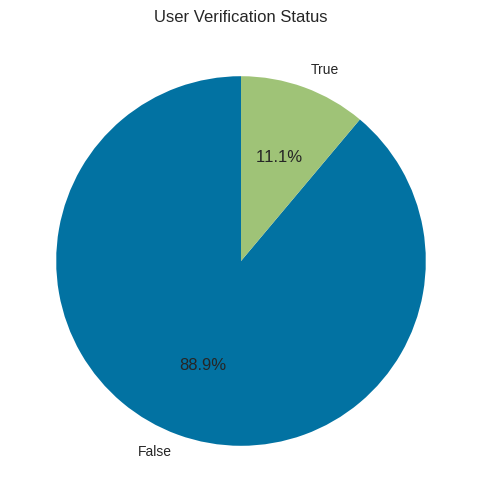

In [111]:
user_status = data['user_verified'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(user_status, labels=user_status.index, autopct='%1.1f%%', startangle=90)
plt.title('User Verification Status')
plt.show()

## User Locations

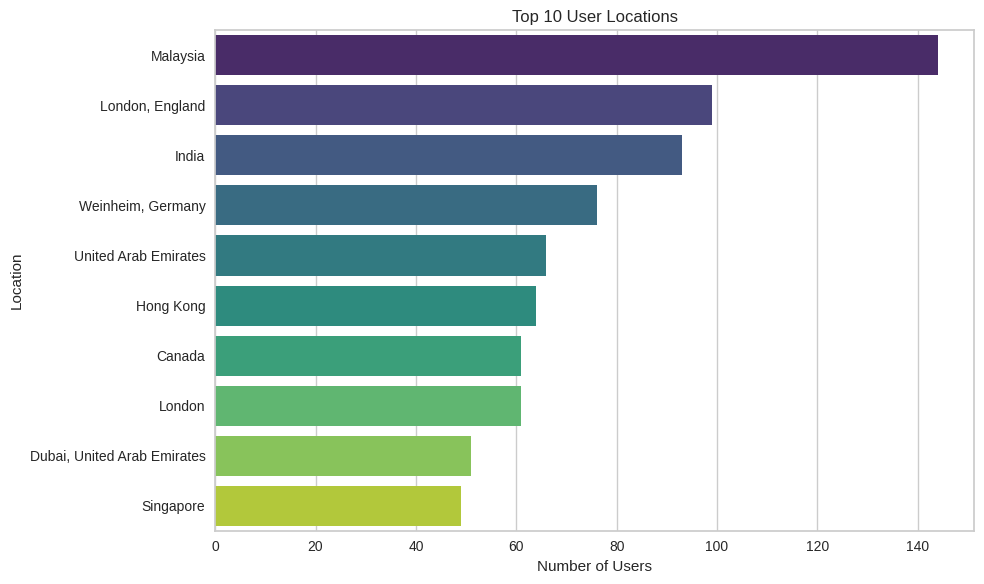

In [112]:
location_counts = data['user_location'].value_counts()
top_locations = location_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="viridis")
plt.title("Top 10 User Locations")
plt.xlabel("Number of Users")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

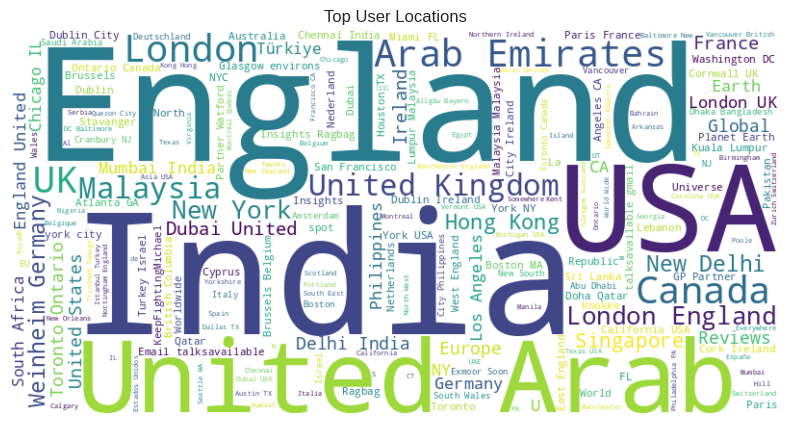

In [113]:
text = " ".join(data['user_location'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top User Locations')
plt.show()

## User Descriptions

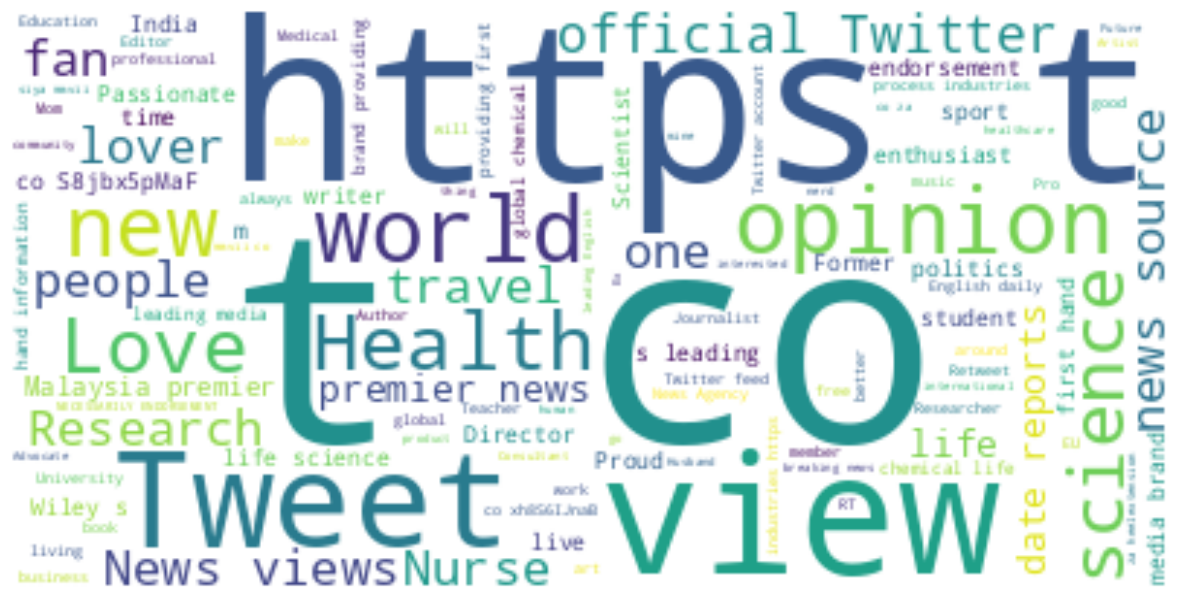

In [114]:
text = " ".join(data['user_description'].dropna())
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Date of Account creation

Text(0, 0.5, 'Frequency')

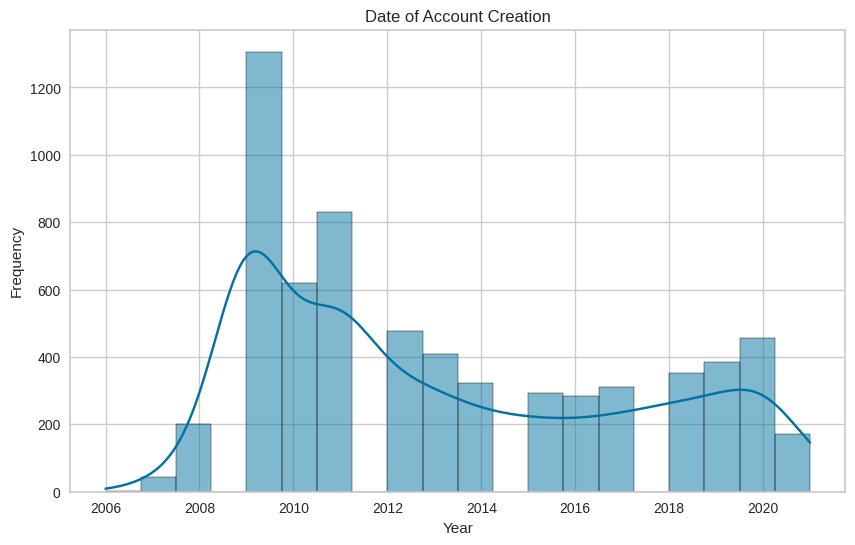

In [115]:
plt.figure(figsize=(10, 6))
sns.histplot(data['user_created'].dt.year, bins=20, kde=True)
plt.title('Date of Account Creation')
plt.xlabel('Year')
plt.ylabel('Frequency')

## Distribution of Followers

In [116]:
data['user_followers'].value_counts()

,count
user_followers,
93,24
26,21
67,19
488,18
79,17
...,...
593,1
2583,1
1582,1


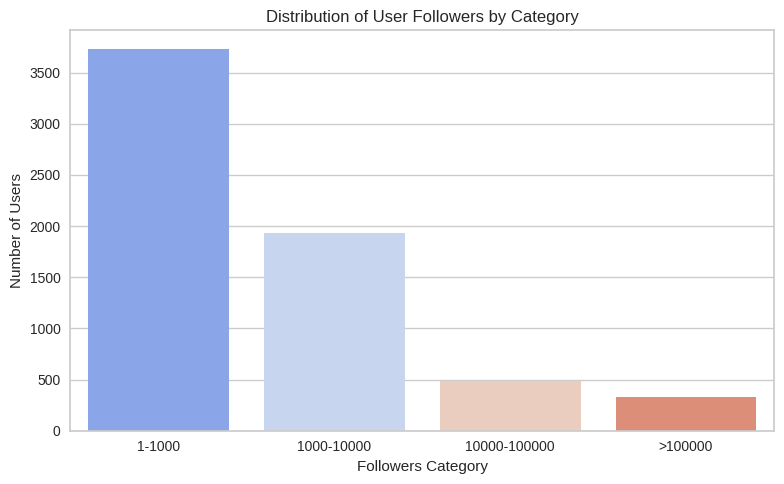

In [125]:
def categorize_followers(followers):
    if followers <= 1000:
        return "1-1000"
    elif followers <= 10000:
        return "1000-10000"
    elif followers <= 100000:
        return "10000-100000"
    else:
        return ">100000"

data['follower_category'] = data['user_followers'].apply(categorize_followers)
follower_category_counts = data['follower_category'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=follower_category_counts.index, y=follower_category_counts.values, palette="coolwarm")
plt.title("Distribution of User Followers by Category")
plt.xlabel("Followers Category")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

## Distribution of Tweet Source

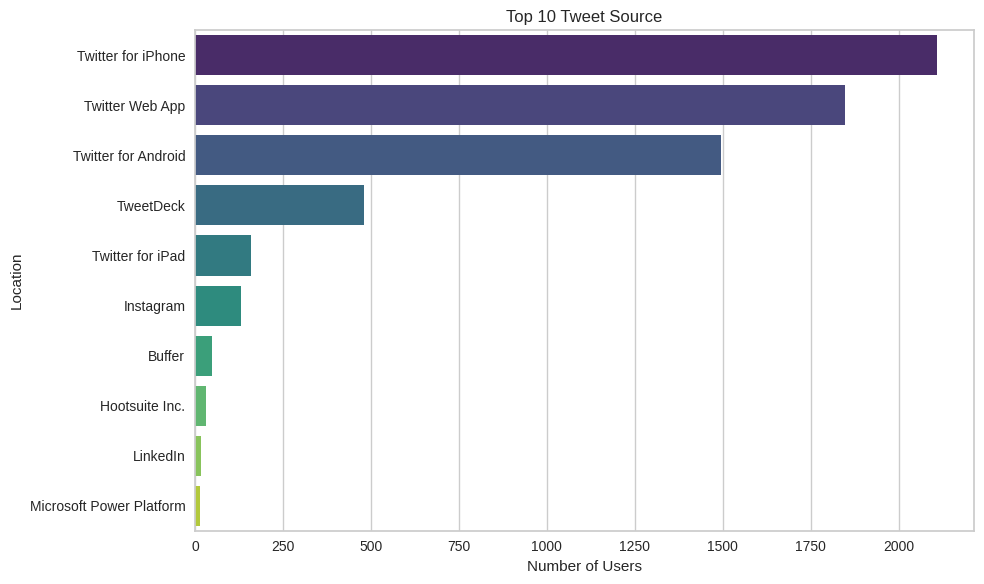

In [118]:
source_count = data['source'].value_counts()
top_source = source_count.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_source.values, y=top_source.index, palette="viridis")
plt.title("Top 10 Tweet Source")
plt.xlabel("Number of Users")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

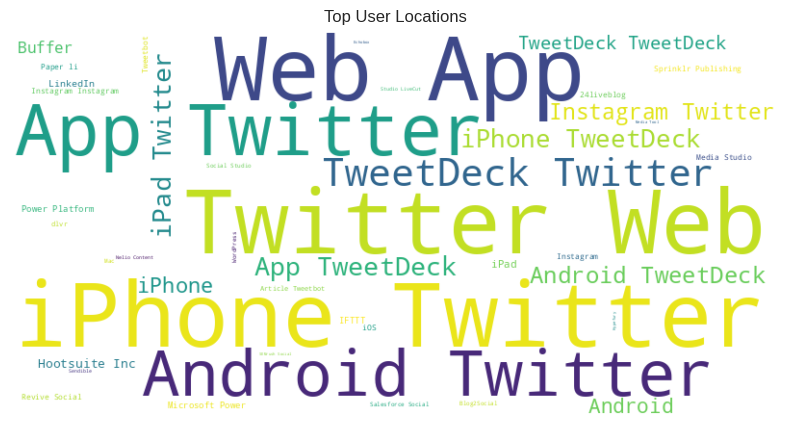

In [119]:
text = " ".join(data['source'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top User Locations')
plt.show()

## Text and Hashtags

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


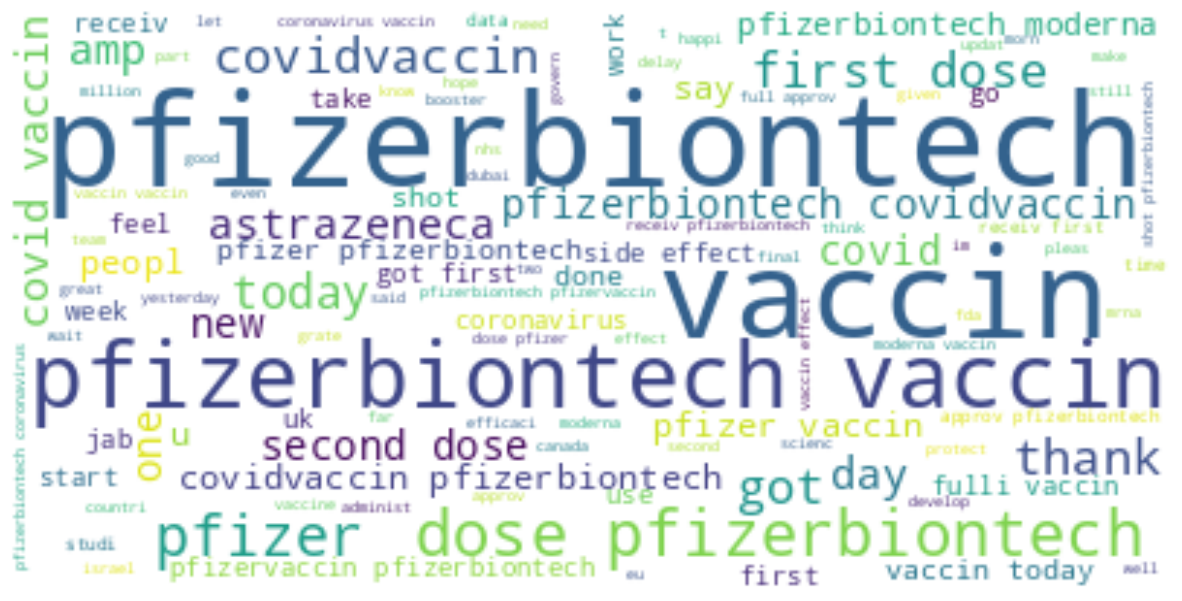

In [120]:
nltk.download('stopwords')
stemmer = nltk.SnowballStemmer("english")
stopword = set(nltk_stopwords.words('english'))

def clean(text):
    text = str(text).lower()
    text = re.sub('', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text
data["text"] = data["text"].apply(clean)

text = " ".join(data['text'].dropna())
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

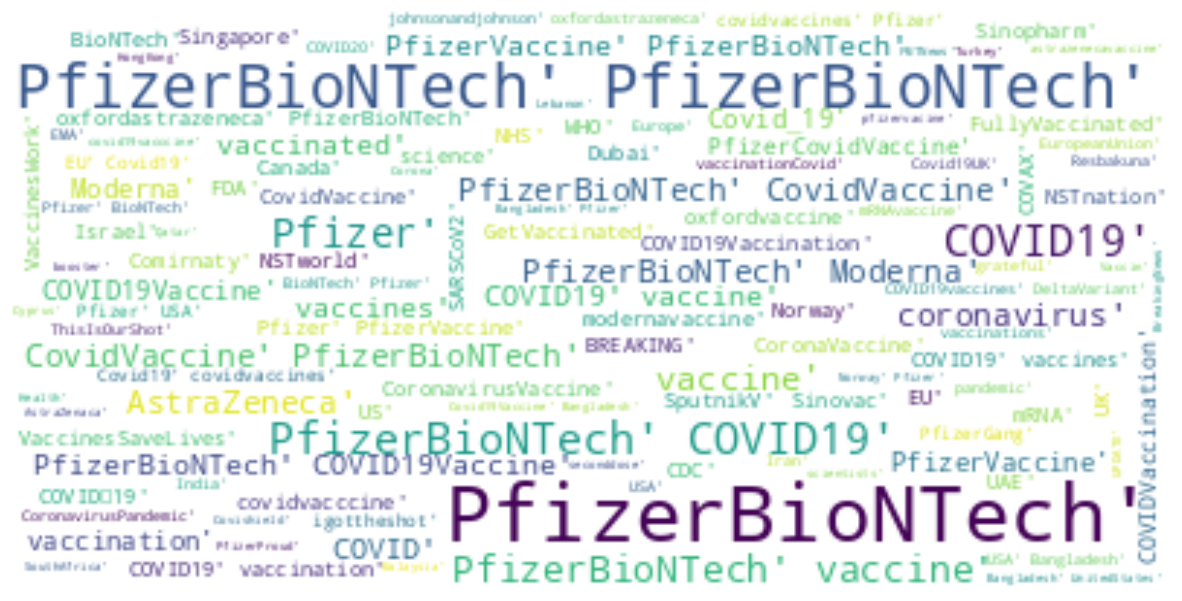

In [121]:
text = " ".join(data['hashtags'].dropna())
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Sentiment Analysis

In [122]:
sentiments = SentimentIntensityAnalyzer()
data["Positive"] = [sentiments.polarity_scores(i)["pos"] for i in data["text"]]
data["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in data["text"]]
data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data["text"]]
data.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet,follower_category,Positive,Negative,Neutral
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,folk said daikon past could treat cytokin stor...,['PfizerBioNTech'],Twitter for Android,0,0,False,1-1000,0.252,0.000,0.748
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,coronavirus sputnikv astrazeneca pfizerbiontec...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False,1-1000,0.000,0.000,1.000
6,1337851215875608579,Gunther Fehlinger,"Austria, Ukraine and Kosovo",End North Stream 2 now - the pipeline of corru...,2013-06-10 17:49:22,2731,5001,69344,False,2020-12-12 20:06:00,bit sad claim fame success vaccin patriot comp...,['vaccination'],Twitter Web App,0,4,False,1000-10000,0.353,0.166,0.481
9,1337842295857623042,Ch.Amjad Ali,Islamabad,#ProudPakistani #LovePakArmy #PMIK @insafiansp...,2012-11-12 04:18:12,671,2368,20469,False,2020-12-12 19:30:33,covidvaccin state start get monday us say pak...,"['CovidVaccine', 'COVID19Vaccine', 'US', 'paku...",Twitter Web App,0,0,False,1-1000,0.000,0.000,1.000
10,1337841934170255365,Tamer Yazar,Turkey-Israel,"Im Market Analyst, also Editor... working (fre...",2009-09-17 16:45:16,1302,78,339,False,2020-12-12 19:29:07,death close mark million peopl wait pfizerbio...,"['PfizerBioNTech', 'Vaccine']",Twitter Web App,0,0,False,1000-10000,0.000,0.302,0.698


In [123]:
a = sum(data["Positive"])
b = sum(data["Negative"])
c = sum(data["Neutral"])

print("Positive: ", a)
print("Negative: ", b)
print("Neutral: ", c)

Positive:  558.9180000000011
Negative:  234.95499999999993
Neutral:  5673.133


In [124]:
if a > b and a > c:
    print(f'Overall sentiment is "Positive".')
elif b > a and b > c:
    print(f'Overall sentiment is "Negative".')
else:
    print(f'Overall sentiment is "Neutral".')

Overall sentiment is "Neutral".
